# AMR Output Exploration

This notebook reads the prepared-input comparison outputs from `outputs/` and helps inspect:

- per-scope model metrics
- side-by-side scope comparison by antibiotic
- zero-feature and skip-rate diagnostics
- the best-performing scope for each antibiotic


In [71]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)


In [72]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'

STRICT_METRICS_PATH = OUTPUT_ROOT / 'strict' / 'metrics.csv'
BROAD_METRICS_PATH = OUTPUT_ROOT / 'broad' / 'metrics.csv'
ALL_METRICS_PATH = OUTPUT_ROOT / 'all' / 'metrics.csv'
STRICT_SUMMARY_PATH = OUTPUT_ROOT / 'strict' / 'dataset_summary.json'
BROAD_SUMMARY_PATH = OUTPUT_ROOT / 'broad' / 'dataset_summary.json'
ALL_SUMMARY_PATH = OUTPUT_ROOT / 'all' / 'dataset_summary.json'

for path in [
    STRICT_METRICS_PATH,
    BROAD_METRICS_PATH,
    ALL_METRICS_PATH,
    STRICT_SUMMARY_PATH,
    BROAD_SUMMARY_PATH,
    ALL_SUMMARY_PATH,
]:
    print(path, 'exists=' + str(path.exists()))


d:\Projects\amr-prediction\outputs\strict\metrics.csv exists=True
d:\Projects\amr-prediction\outputs\broad\metrics.csv exists=True
d:\Projects\amr-prediction\outputs\all\metrics.csv exists=True
d:\Projects\amr-prediction\outputs\strict\dataset_summary.json exists=True
d:\Projects\amr-prediction\outputs\broad\dataset_summary.json exists=True
d:\Projects\amr-prediction\outputs\all\dataset_summary.json exists=True


In [73]:
strict_metrics = pd.read_csv(STRICT_METRICS_PATH)
broad_metrics = pd.read_csv(BROAD_METRICS_PATH)
all_metrics = pd.read_csv(ALL_METRICS_PATH)
scope_metrics = pd.concat([strict_metrics, broad_metrics, all_metrics], ignore_index=True)

strict_summary = json.loads(STRICT_SUMMARY_PATH.read_text(encoding='utf-8'))
broad_summary = json.loads(BROAD_SUMMARY_PATH.read_text(encoding='utf-8'))
all_summary = json.loads(ALL_SUMMARY_PATH.read_text(encoding='utf-8'))

scope_order = ['strict', 'broad', 'all']
scope_metrics['scope'] = pd.Categorical(scope_metrics['scope'], categories=scope_order, ordered=True)
scope_metrics = scope_metrics.sort_values(['scope', 'roc_auc', 'Antibiotic'], ascending=[True, False, True]).reset_index(drop=True)

display(scope_metrics)


,scope,Antibiotic,n_samples,n_susceptible,n_resistant,n_positive,n_negative,positive_label,positive_fraction,feature_count,zero_feature_rows,roc_auc,average_precision,accuracy,precision,recall,mean_fold_roc_auc,status
0,strict,ciprofloxacin,6550,5951,599,599,5951,resistant,0.091450,52,5932,0.997120,0.992536,0.997863,0.980296,0.996661,0.998199,trained
1,strict,chloramphenicol,6730,6146,584,584,6146,resistant,0.086776,44,6147,0.992727,0.983949,0.998217,0.991409,0.988014,0.993832,trained
2,strict,trimethoprim-sulfamethoxazole,6808,6494,314,314,6494,resistant,0.046122,60,3952,0.991499,0.955598,0.997062,0.968153,0.968153,0.993044,trained
3,strict,tetracycline,6780,1941,4839,4839,1941,resistant,0.713717,28,1924,0.987469,0.991693,0.990413,0.993386,0.993180,0.988800,trained
4,strict,nalidixic acid,6789,5974,815,815,5974,resistant,0.120047,80,5943,0.987357,0.981155,0.993666,0.966184,0.981595,0.990600,trained
5,strict,sulfisoxazole,6558,3845,2713,2713,3845,resistant,0.413693,12,3844,0.984747,0.973923,0.987649,0.985609,0.984519,0.986565,trained
6,strict,gentamicin,6459,5575,884,884,5575,resistant,0.136863,64,5480,0.978014,0.935605,0.980492,0.898109,0.967195,0.980367,trained
7,strict,streptomycin,6050,2850,3200,3200,2850,resistant,0.528926,60,2516,0.958657,0.950007,0.942149,0.921847,0.973125,0.960602,trained
8,strict,kanamycin,2772,2304,468,468,2304,resistant,0.168831,12,2341,0.943029,0.911921,0.978355,0.974419,0.895299,0.947494,trained
9,strict,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,48,5457,0.761509,0.742092,0.830543,0.978423,0.538934,0.766853,trained


In [74]:
scope_run_summary = pd.DataFrame(
    [
        {'scope': strict_summary['scope'], 'prepared_input_dir': strict_summary['prepared_input_dir'], 'n_antibiotics': len(strict_summary['prepared_input_summary'])},
        {'scope': broad_summary['scope'], 'prepared_input_dir': broad_summary['prepared_input_dir'], 'n_antibiotics': len(broad_summary['prepared_input_summary'])},
        {'scope': all_summary['scope'], 'prepared_input_dir': all_summary['prepared_input_dir'], 'n_antibiotics': len(all_summary['prepared_input_summary'])},
    ]
)
display(scope_run_summary)

scope_input_summary = pd.concat(
    [
        pd.DataFrame(strict_summary['prepared_input_summary']).assign(scope='strict'),
        pd.DataFrame(broad_summary['prepared_input_summary']).assign(scope='broad'),
        pd.DataFrame(all_summary['prepared_input_summary']).assign(scope='all'),
    ],
    ignore_index=True,
)
display(scope_input_summary.sort_values(['scope', 'n_samples', 'Antibiotic'], ascending=[True, False, True]))


,scope,prepared_input_dir,n_antibiotics
0,strict,data\model_inputs\strict,14
1,broad,data\model_inputs\broad,14
2,all,data\model_inputs\all,14


,Antibiotic,table_path,n_samples,n_susceptible,n_resistant,feature_count,zero_feature_rows,scope
28,ampicillin,data\model_inputs\all\model_input__ampicillin.csv,6810,4370,2440,556,0,all
29,trimethoprim-sulfamethoxazole,data\model_inputs\all\model_input__trimethoprim_sulfamethoxazole.csv,6808,6494,314,556,0,all
30,ceftriaxone,data\model_inputs\all\model_input__ceftriaxone.csv,6807,5594,1213,552,0,all
31,nalidixic acid,data\model_inputs\all\model_input__nalidixic_acid.csv,6789,5974,815,520,0,all
32,tetracycline,data\model_inputs\all\model_input__tetracycline.csv,6780,1941,4839,544,0,all
33,chloramphenicol,data\model_inputs\all\model_input__chloramphenicol.csv,6730,6146,584,520,0,all
34,cefoxitin,data\model_inputs\all\model_input__cefoxitin.csv,6715,5917,798,544,0,all
35,sulfisoxazole,data\model_inputs\all\model_input__sulfisoxazole.csv,6558,3845,2713,524,0,all
36,ciprofloxacin,data\model_inputs\all\model_input__ciprofloxacin.csv,6550,5951,599,500,0,all
37,gentamicin,data\model_inputs\all\model_input__gentamicin.csv,6459,5575,884,540,0,all


,scope,Antibiotic,status,roc_auc,average_precision,accuracy,precision,recall,feature_count,zero_feature_rows,n_samples,n_susceptible,n_resistant
0,strict,ciprofloxacin,trained,0.997120,0.992536,0.997863,0.980296,0.996661,52,5932,6550,5951,599
1,strict,chloramphenicol,trained,0.992727,0.983949,0.998217,0.991409,0.988014,44,6147,6730,6146,584
2,strict,trimethoprim-sulfamethoxazole,trained,0.991499,0.955598,0.997062,0.968153,0.968153,60,3952,6808,6494,314
3,strict,tetracycline,trained,0.987469,0.991693,0.990413,0.993386,0.993180,28,1924,6780,1941,4839
4,strict,nalidixic acid,trained,0.987357,0.981155,0.993666,0.966184,0.981595,80,5943,6789,5974,815
5,strict,sulfisoxazole,trained,0.984747,0.973923,0.987649,0.985609,0.984519,12,3844,6558,3845,2713
6,strict,gentamicin,trained,0.978014,0.935605,0.980492,0.898109,0.967195,64,5480,6459,5575,884
7,strict,streptomycin,trained,0.958657,0.950007,0.942149,0.921847,0.973125,60,2516,6050,2850,3200
8,strict,kanamycin,trained,0.943029,0.911921,0.978355,0.974419,0.895299,12,2341,2772,2304,468
9,strict,ampicillin,trained,0.761509,0.742092,0.830543,0.978423,0.538934,48,5457,6810,4370,2440


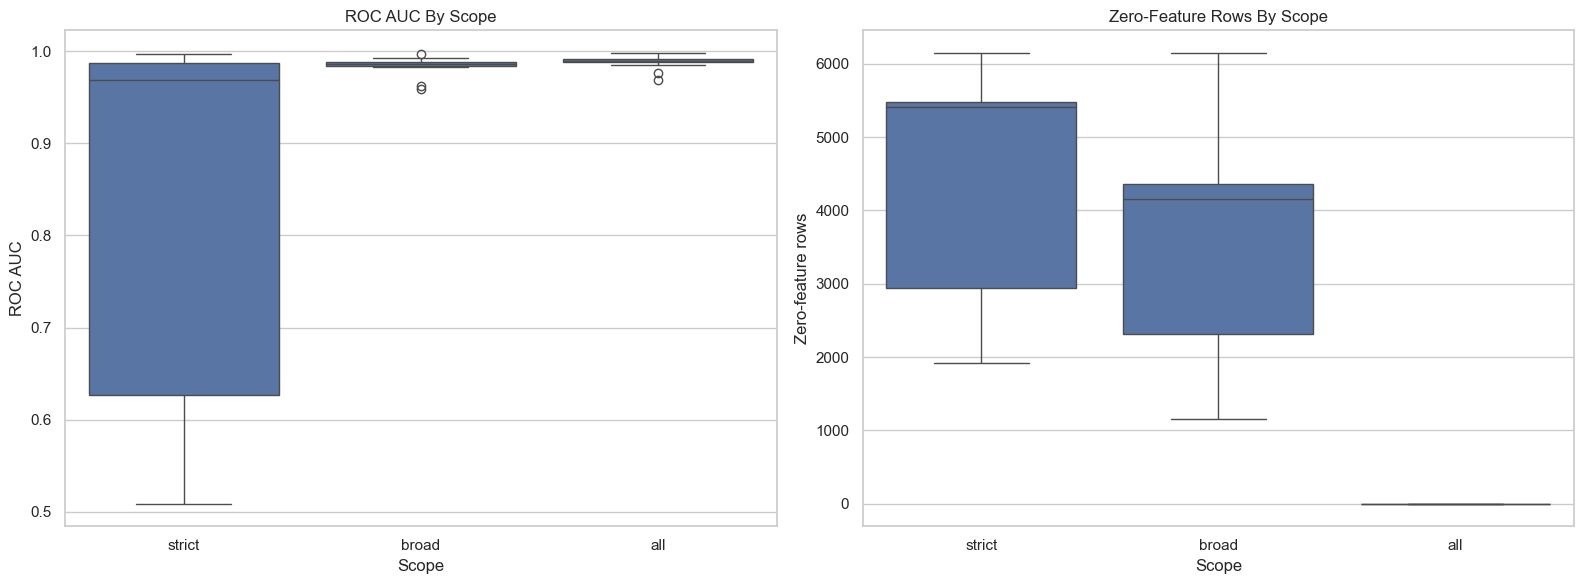

In [75]:
comparison_cols = [
    'scope', 'Antibiotic', 'status', 'roc_auc', 'average_precision', 'accuracy', 'precision', 'recall',
    'feature_count', 'zero_feature_rows', 'n_samples', 'n_susceptible', 'n_resistant'
]
display(scope_metrics[comparison_cols])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=scope_metrics, x='scope', y='roc_auc', order=scope_order, ax=axes[0])
axes[0].set_title('ROC AUC By Scope')
axes[0].set_xlabel('Scope')
axes[0].set_ylabel('ROC AUC')

sns.boxplot(data=scope_metrics, x='scope', y='zero_feature_rows', order=scope_order, ax=axes[1])
axes[1].set_title('Zero-Feature Rows By Scope')
axes[1].set_xlabel('Scope')
axes[1].set_ylabel('Zero-feature rows')

plt.tight_layout()
plt.show()


In [76]:
status_summary = (
    scope_metrics.groupby(['scope', 'status'], observed=True)
    .size()
    .reset_index(name='n_antibiotics')
    .sort_values(['scope', 'status'])
    .reset_index(drop=True)
)
display(status_summary)

skip_rows = scope_metrics[scope_metrics['status'] != 'trained'].copy()
if not skip_rows.empty:
    display(skip_rows.sort_values(['scope', 'Antibiotic']))


,scope,status,n_antibiotics
0,strict,trained,14
1,broad,trained,14
2,all,trained,14


In [77]:
per_antibiotic = scope_metrics.pivot_table(
    index='Antibiotic',
    columns='scope',
    values=['roc_auc', 'average_precision', 'accuracy', 'feature_count', 'zero_feature_rows', 'status'],
    aggfunc='first',
)
per_antibiotic.columns = [f'{metric}_{scope}' for metric, scope in per_antibiotic.columns]
per_antibiotic = per_antibiotic.reset_index()
display(per_antibiotic.sort_values('Antibiotic'))


,Antibiotic,accuracy_strict,accuracy_broad,accuracy_all,average_precision_strict,average_precision_broad,average_precision_all,feature_count_strict,feature_count_broad,feature_count_all,roc_auc_strict,roc_auc_broad,roc_auc_all,status_strict,status_broad,status_all,zero_feature_rows_strict,zero_feature_rows_broad,zero_feature_rows_all
0,amoxicillin-clavulanic acid,0.784218,0.990421,0.990258,0.163111,0.968750,0.976916,32,76,512,0.508633,0.985421,0.987894,trained,trained,trained,5439,4351,0
1,ampicillin,0.830543,0.986344,0.986197,0.742092,0.980189,0.985714,48,100,556,0.761509,0.983943,0.989059,trained,trained,trained,5457,4367,0
2,cefoxitin,0.286969,0.995235,0.994043,0.139406,0.963598,0.972962,44,100,544,0.549999,0.985730,0.989064,trained,trained,trained,5382,4352,0
3,ceftiofur,0.405109,0.993824,0.992981,0.239474,0.977851,0.979936,28,52,384,0.582208,0.987717,0.988986,trained,trained,trained,2640,2028,0
4,ceftriaxone,0.339797,0.994271,0.993536,0.204569,0.978368,0.977307,44,100,552,0.561527,0.988749,0.988545,trained,trained,trained,5458,4365,0
5,chloramphenicol,0.998217,0.998217,0.996582,0.983949,0.983949,0.984787,44,44,520,0.992727,0.992727,0.995116,trained,trained,trained,6147,6147,0
6,ciprofloxacin,0.997863,0.997863,0.997557,0.992536,0.992536,0.995827,52,52,500,0.997120,0.997120,0.998248,trained,trained,trained,5932,5932,0
7,gentamicin,0.980492,0.979099,0.978480,0.935605,0.954461,0.955275,64,148,540,0.978014,0.983445,0.985629,trained,trained,trained,5480,2427,0
8,kanamycin,0.978355,0.984848,0.981602,0.911921,0.942693,0.948632,12,80,280,0.943029,0.962743,0.976134,trained,trained,trained,2341,1159,0
9,nalidixic acid,0.993666,0.993666,0.995286,0.981155,0.981155,0.985394,80,80,520,0.987357,0.987357,0.991962,trained,trained,trained,5943,5943,0


In [78]:
trained_only = scope_metrics[scope_metrics['status'] == 'trained'].copy()
best_scope = (
    trained_only.sort_values(['Antibiotic', 'roc_auc', 'average_precision', 'accuracy'], ascending=[True, False, False, False])
    .drop_duplicates(subset=['Antibiotic'], keep='first')
    [['Antibiotic', 'scope', 'roc_auc', 'average_precision', 'accuracy', 'feature_count', 'zero_feature_rows']]
    .rename(columns={'scope': 'best_scope', 'roc_auc': 'best_roc_auc', 'average_precision': 'best_average_precision', 'accuracy': 'best_accuracy'})
)
display(best_scope.sort_values(['best_roc_auc', 'Antibiotic'], ascending=[False, True]).reset_index(drop=True))


,Antibiotic,best_scope,best_roc_auc,best_average_precision,best_accuracy,feature_count,zero_feature_rows
0,ciprofloxacin,all,0.998248,0.995827,0.997557,500,0
1,chloramphenicol,all,0.995116,0.984787,0.996582,520,0
2,trimethoprim-sulfamethoxazole,all,0.993198,0.969412,0.995300,556,0
3,tetracycline,all,0.992245,0.996077,0.990560,544,0
4,nalidixic acid,all,0.991962,0.985394,0.995286,520,0
5,sulfisoxazole,all,0.991930,0.989804,0.987496,524,0
6,cefoxitin,all,0.989064,0.972962,0.994043,544,0
7,ampicillin,all,0.989059,0.985714,0.986197,556,0
8,ceftiofur,all,0.988986,0.979936,0.992981,384,0
9,ceftriaxone,broad,0.988749,0.978368,0.994271,100,4365


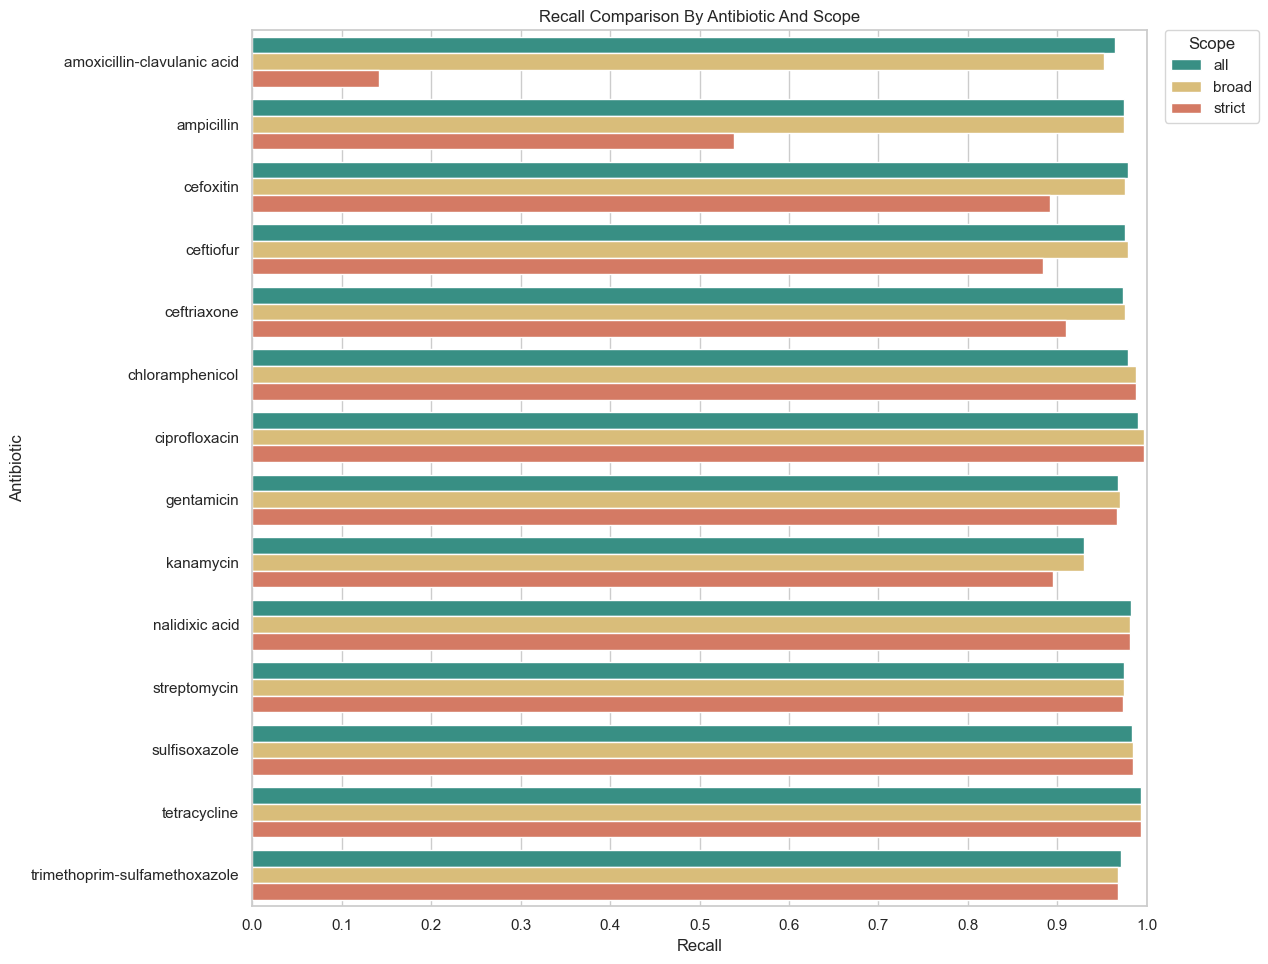

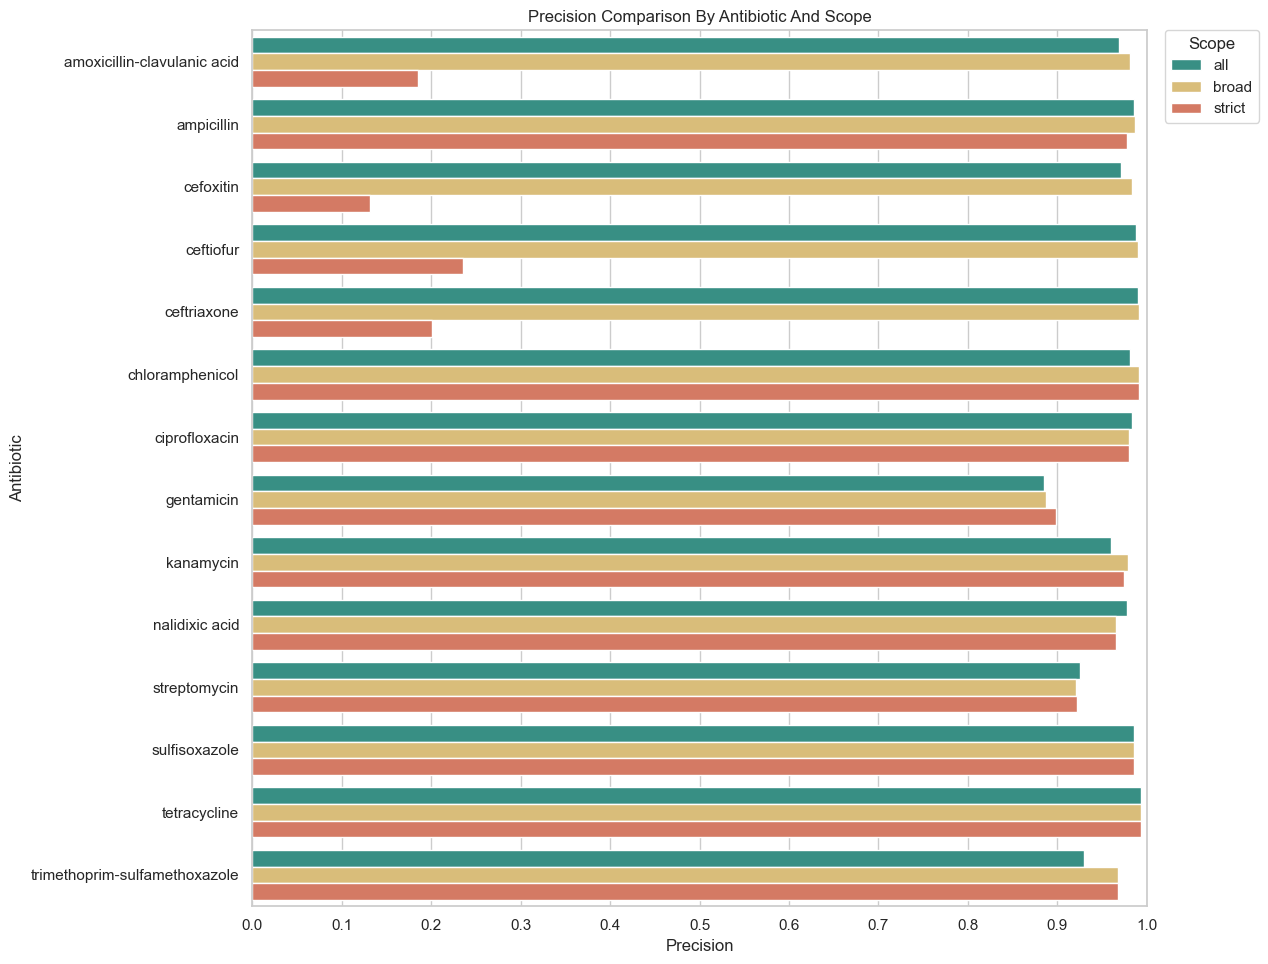

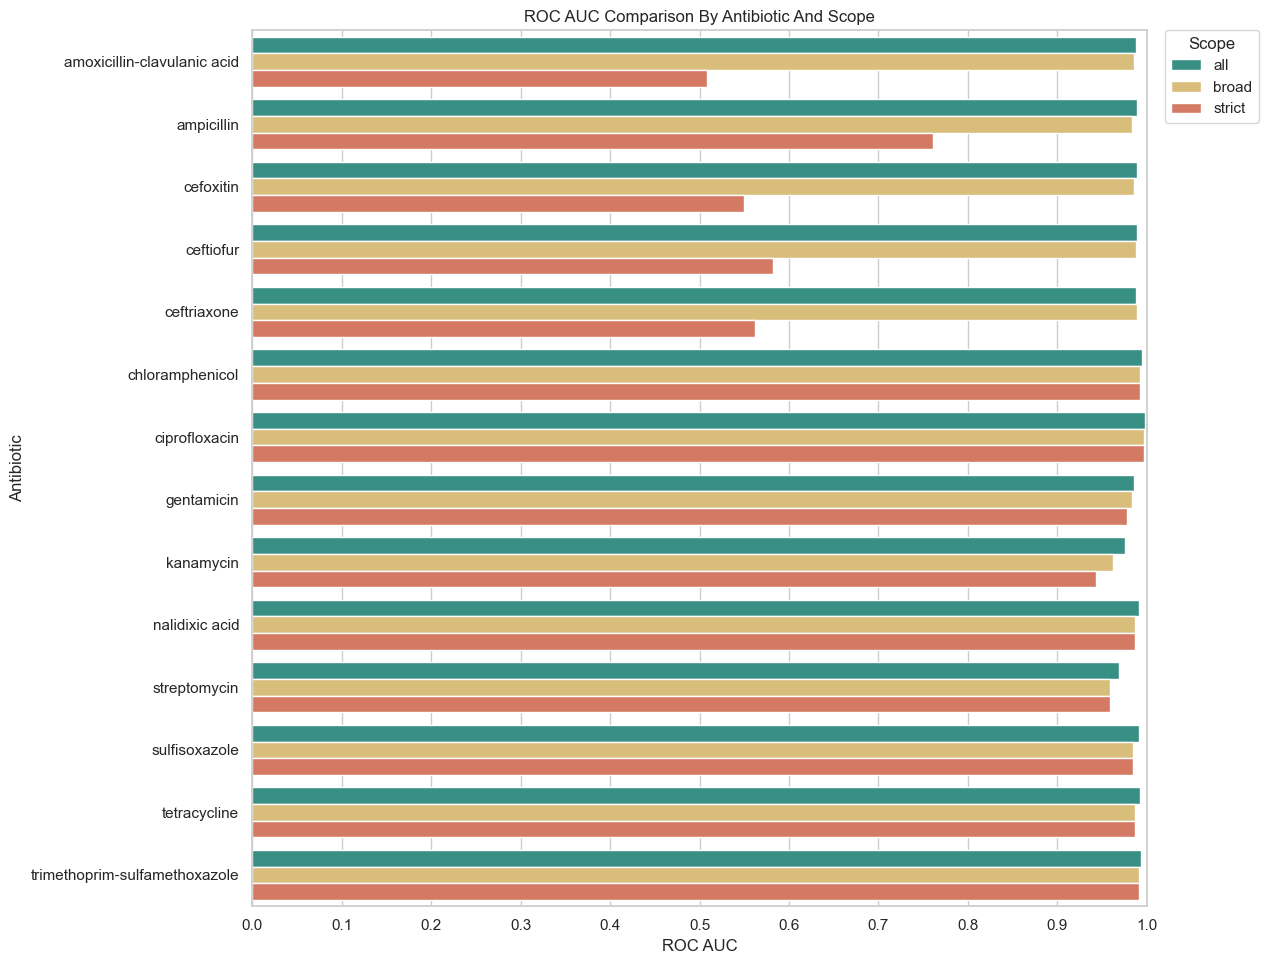

In [79]:
scope_display_order = ['all', 'broad', 'strict']
scope_palette = {'all': '#2a9d8f', 'broad': '#e9c46a', 'strict': '#e76f51'}
metric_specs = [
    ('recall', 'Recall Comparison By Antibiotic And Scope', 'Recall'),
    ('precision', 'Precision Comparison By Antibiotic And Scope', 'Precision'),
    ('roc_auc', 'ROC AUC Comparison By Antibiotic And Scope', 'ROC AUC'),
]

plot_height = max(8, 0.7 * trained_only['Antibiotic'].nunique())
x_ticks = [value / 10 for value in range(0, 11)]

for metric_name, title, xlabel in metric_specs:
    plot_df = trained_only[['Antibiotic', 'scope', metric_name]].copy()
    plot_df['scope'] = pd.Categorical(plot_df['scope'], categories=scope_display_order, ordered=True)
    plot_df = plot_df.sort_values(['Antibiotic', 'scope']).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(15, plot_height))
    sns.barplot(
        data=plot_df,
        x=metric_name,
        y='Antibiotic',
        hue='scope',
        hue_order=scope_display_order,
        palette=scope_palette,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Antibiotic')
    ax.set_xlim(0, 1)
    ax.set_xticks(x_ticks)
    ax.legend(title='Scope', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout(rect=(0, 0, 0.86, 1))
    plt.show()


In [80]:
scope_display_order = ['all', 'broad', 'strict']
all_rows = scope_metrics.copy()
all_rows['scope'] = pd.Categorical(all_rows['scope'], categories=scope_display_order, ordered=True)
all_rows = all_rows.sort_values(['Antibiotic', 'scope']).reset_index(drop=True)
display(all_rows)


,scope,Antibiotic,n_samples,n_susceptible,n_resistant,n_positive,n_negative,positive_label,positive_fraction,feature_count,zero_feature_rows,roc_auc,average_precision,accuracy,precision,recall,mean_fold_roc_auc,status
0,all,amoxicillin-clavulanic acid,6159,5262,897,897,5262,resistant,0.145641,512,0,0.987894,0.976916,0.990258,0.968645,0.964326,0.988380,trained
1,broad,amoxicillin-clavulanic acid,6159,5262,897,897,5262,resistant,0.145641,76,4351,0.985421,0.968750,0.990421,0.981609,0.952062,0.987581,trained
2,strict,amoxicillin-clavulanic acid,6159,5262,897,897,5262,resistant,0.145641,32,5439,0.508633,0.163111,0.784218,0.185131,0.141583,0.517978,trained
3,all,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,556,0,0.989059,0.985714,0.986197,0.986318,0.975000,0.989623,trained
4,broad,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,100,4367,0.983943,0.980189,0.986344,0.986727,0.975000,0.986288,trained
5,strict,ampicillin,6810,4370,2440,2440,4370,resistant,0.358297,48,5457,0.761509,0.742092,0.830543,0.978423,0.538934,0.766853,trained
6,all,cefoxitin,6715,5917,798,798,5917,resistant,0.118838,544,0,0.989064,0.972962,0.994043,0.971393,0.978697,0.989817,trained
7,broad,cefoxitin,6715,5917,798,798,5917,resistant,0.118838,100,4352,0.985730,0.963598,0.995235,0.983586,0.976190,0.987960,trained
8,strict,cefoxitin,6715,5917,798,798,5917,resistant,0.118838,44,5382,0.549999,0.139406,0.286969,0.131511,0.892231,0.555726,trained
9,all,ceftiofur,3562,2854,708,708,2854,resistant,0.198765,384,0,0.988986,0.979936,0.992981,0.988555,0.975989,0.989461,trained
